<a href="https://colab.research.google.com/github/VenkataBhanuTejaKonijeti/Predictive-analytics/blob/Student-admission-prediction/student_admission_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

R2 Score: 0.8212
RMSE: 0.0679


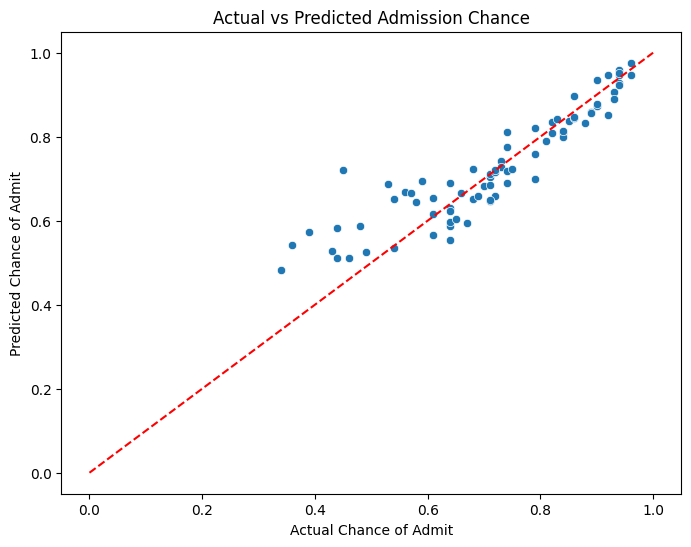

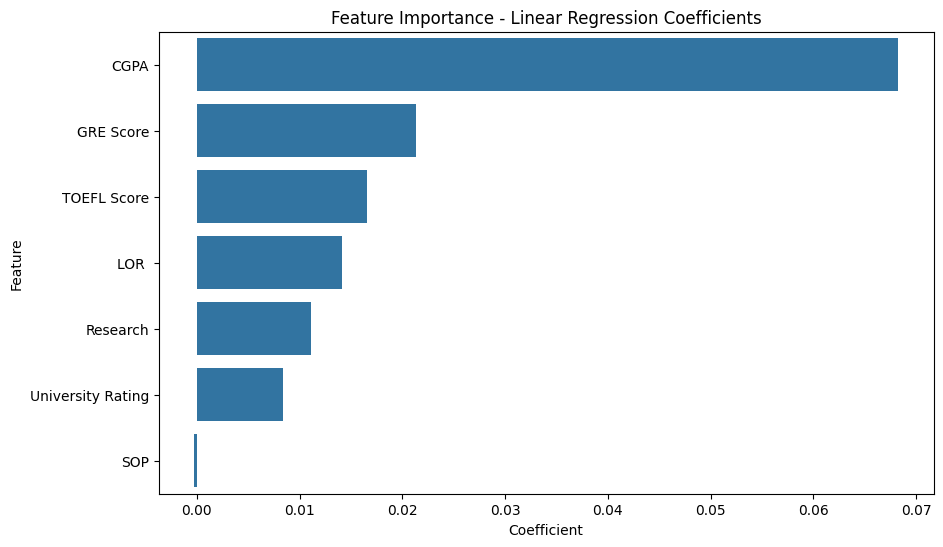

In [12]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
url = "https://raw.githubusercontent.com/divyansha1115/Graduate-Admission-Prediction/master/Admission_Predict.csv"
df = pd.read_csv(url)

# Prepare data
if 'Serial No.' in df.columns:
    df = df.drop('Serial No.', axis=1)
X = df.drop('Chance of Admit ', axis=1)
y = df['Chance of Admit ']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict and evaluate
y_pred = model.predict(X_test)
print(f"R2 Score: {r2_score(y_test, y_pred):.4f}")
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"RMSE: {rmse:.4f}")

# Plot Actual vs Predicted
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel('Actual Chance of Admit')
plt.ylabel('Predicted Chance of Admit')
plt.title('Actual vs Predicted Admission Chance')
plt.show()

# Plot Feature Importance
feature_names = X.columns
coefficients = model.coef_
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
}).sort_values(by='Coefficient', key=abs, ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=coef_df, x='Coefficient', y='Feature')
plt.title('Feature Importance - Linear Regression Coefficients')
plt.show()
